In [8]:
import os
import ast
import pandas as pd
import spacy
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

# UPDATED: using lg model for better NER accuracy
nlp = spacy.load("en_core_web_lg", disable=["parser", "lemmatizer"])

# KeyBERT uses sentence transformers under the hood
kw_model = KeyBERT(model=SentenceTransformer("all-MiniLM-L6-v2", device="cuda"))

# ── CUSTOM ENTITY DICTIONARY ──
# domain-specific entities spaCy might miss or mislabel
# combines with spaCy NER for maximum coverage
CUSTOM_ENTITIES = {
    "ORG": [
        "Google", "Microsoft", "OpenAI", "Meta", "Amazon", "Apple",
        "Anthropic", "DeepMind", "Nvidia", "IBM", "Tesla", "Samsung",
        "Twitter", "YouTube", "Netflix", "Uber", "Lyft",
        "Goldman Sachs", "McKinsey", "Adobe", "Salesforce", "Spotify",
        "TikTok", "Reddit", "LinkedIn", "GitHub"
    ],
    "PRODUCT": [
        "ChatGPT", "GPT-4", "GPT-3", "GPT4", "GPT3", "Copilot",
        "Gemini", "Claude", "Llama", "Midjourney", "Stable Diffusion",
        "DALL-E", "Sora", "Grok", "Perplexity", "GitHub Copilot",
        "AutoGPT", "LangChain", "Cursor", "Bard", "Bing", "Alexa",
        "Siri", "Watson"
    ],
    "PERSON": [
        "Sam Altman", "Elon Musk", "Jensen Huang", "Sundar Pichai",
        "Bill Gates", "Jeff Bezos", "Mark Zuckerberg", "Geoffrey Hinton",
        "Yann LeCun", "Andrej Karpathy", "Demis Hassabis", "Ilya Sutskever",
        "Satya Nadella", "Tim Cook", "Altman", "Zuckerberg", "Musk"
    ],
    "CONCEPT": [
        "AI", "AGI", "LLM", "UBI", "automation", "machine learning",
        "deep learning", "neural network", "large language model",
        "generative AI", "vibe coding", "prompt engineering"
    ]
}

print("spaCy model loaded:", nlp.meta["name"])
print("KeyBERT ready")
print("Custom entities defined:", sum(len(v) for v in CUSTOM_ENTITIES.values()), "entities across", len(CUSTOM_ENTITIES), "types")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7010.81it/s]


spaCy model loaded: core_web_lg
KeyBERT ready
Custom entities defined: 79 entities across 4 types


In [2]:
# load comments with sentiment and topic labels - output from 04_topic_modeling.ipynb
df = pd.read_csv("../data/processed/comments_topics.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample text:")
print(df["text"].iloc[0][:200])

Shape: (27330, 18)
Columns: ['video_id', 'video_name', 'comment_id', 'author', 'text', 'likes', 'published_at', 'reply_count', 'text_clean', 'text_lemma', 'text_for_model', 'sentiment', 'score_negative', 'score_neutral', 'score_positive', 'confidence', 'topic', 'topic_name']

Sample text:
Wow. It blows my mind the amount of commenters who thought that these videos were made by Ai or a software program. They've always been drawn by hand on an actual whiteboard with dry-erase markers. I 


In [9]:
# entity types to keep from spaCy
RELEVANT_TYPES = {"ORG", "PERSON", "PRODUCT", "GPE", "CONCEPT"}

def extract_entities_combined(text, doc):
    """
    Combines spaCy NER with custom entity dictionary.
    spaCy catches unknown entities, custom dict catches domain-specific ones.
    """
    found = {}  # use dict to avoid duplicates: entity_text -> label
    
    # Step 1: spaCy NER
    for ent in doc.ents:
        if ent.label_ in RELEVANT_TYPES and len(ent.text.strip()) > 1:
            found[ent.text.strip()] = ent.label_
    
    # Step 2: custom entity scan - catches what spaCy misses
    text_lower = text.lower()
    for label, entities in CUSTOM_ENTITIES.items():
        for entity in entities:
            if entity.lower() in text_lower:
                found[entity] = label  # custom dict overwrites spaCy if conflict
    
    return list(found.items())

# run combined NER on all comments
texts = df["text"].tolist()
all_entities = []

for text, doc in tqdm(
    zip(texts, nlp.pipe(texts, batch_size=256)),
    total=len(texts),
    desc="NER"
):
    all_entities.append(extract_entities_combined(text, doc))

df["entities"] = all_entities

print("Done.")
print("Sample entities:", df["entities"].iloc[0])
print("\nComments with at least one entity:", (df["entities"].apply(len) > 0).sum())

NER: 100%|██████████| 27330/27330 [04:09<00:00, 109.36it/s]

Done.
Sample entities: [('Bing', 'PRODUCT'), ('AI', 'CONCEPT')]

Comments with at least one entity: 17559


In [10]:
# flatten all entities into one list for counting
all_entity_list = [
    (ent_text, ent_label)
    for entities in df["entities"]
    for ent_text, ent_label in entities
]

# count by entity text
entity_counts = Counter([text for text, label in all_entity_list])

# count by entity type
type_counts = Counter([label for text, label in all_entity_list])

print("Total entity mentions:", len(all_entity_list))
print("\nEntity type distribution:")
for etype, count in type_counts.most_common():
    print(f"  {etype}: {count}")

print("\nTop 25 most mentioned entities:")
for entity, count in entity_counts.most_common(25):
    print(f"  {entity}: {count}")

Total entity mentions: 27382

Entity type distribution:
  CONCEPT: 17044
  ORG: 5565
  PERSON: 2381
  GPE: 1314
  PRODUCT: 1078

Top 25 most mentioned entities:
  AI: 14437
  AGI: 728
  LLM: 645
  UBI: 459
  automation: 457
  YouTube: 244
  Google: 238
  ChatGPT: 226
  US: 179
  Claude: 134
  Bing: 110
  Microsoft: 101
  Gemini: 96
  India: 91
  vibe coding: 86
  generative AI: 85
  Altman: 80
  Meta: 79
  China: 77
  Amazon: 74
  Nvidia: 71
  OpenAI: 70
  Ai: 66
  America: 66
  Musk: 61


In [11]:
# separate entities by type for targeted analysis
org_counter = Counter([
    text for entities in df["entities"]
    for text, label in entities
    if label == "ORG"
])

product_counter = Counter([
    text for entities in df["entities"]
    for text, label in entities
    if label == "PRODUCT"
])

person_counter = Counter([
    text for entities in df["entities"]
    for text, label in entities
    if label == "PERSON"
])

concept_counter = Counter([
    text for entities in df["entities"]
    for text, label in entities
    if label == "CONCEPT"
])

gpe_counter = Counter([
    text for entities in df["entities"]
    for text, label in entities
    if label == "GPE"
])

print("Top 10 Organizations:")
for k, v in org_counter.most_common(10):
    print(f"  {k}: {v}")

print("\nTop 10 AI Products/Tools:")
for k, v in product_counter.most_common(10):
    print(f"  {k}: {v}")

print("\nTop 10 People:")
for k, v in person_counter.most_common(10):
    print(f"  {k}: {v}")

print("\nTop 10 Concepts:")
for k, v in concept_counter.most_common(10):
    print(f"  {k}: {v}")

print("\nTop 10 Locations:")
for k, v in gpe_counter.most_common(10):
    print(f"  {k}: {v}")

Top 10 Organizations:
  YouTube: 244
  Google: 238
  Microsoft: 101
  Meta: 79
  Amazon: 74
  Nvidia: 71
  OpenAI: 70
  Uber: 60
  Renaissance: 56
  Apple: 51

Top 10 AI Products/Tools:
  ChatGPT: 226
  Claude: 134
  Bing: 110
  Gemini: 96
  Copilot: 41
  Grok: 36
  Sora: 22
  Cursor: 21
  Excel: 14
  ColdFusion: 13

Top 10 People:
  Altman: 80
  Musk: 61
  Dagogo: 54
  Sam Altman: 44
  Marx: 38
  Elon Musk: 29
  claude: 29
  Ai: 22
  Zor Veyl: 19
  Karl Marx: 19

Top 10 Concepts:
  AI: 14437
  AGI: 728
  LLM: 645
  UBI: 459
  automation: 457
  vibe coding: 86
  generative AI: 85
  machine learning: 58
  neural network: 37
  large language model: 33

Top 10 Locations:
  US: 179
  India: 91
  China: 77
  America: 66
  USA: 53
  Philippines: 37
  IA: 28
  Skynet: 25
  UK: 23
  Canada: 19


In [12]:
# extract top 3 keywords per comment using KeyBERT
# keyphrase_ngram_range=(1,2) gets both single words and two-word phrases
# use_mmr=True adds diversity to avoid repetitive keywords
# top_n=3 keeps it lightweight - 3 keywords per comment is enough

def extract_keywords(text):
    if not isinstance(text, str) or len(text.strip()) < 20:
        return []
    try:
        keywords = kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 2),
            stop_words="english",
            use_mmr=True,
            diversity=0.5,
            top_n=3
        )
        return [kw for kw, score in keywords]
    except:
        return []

# apply to all comments - use raw text for better keyword quality
df["keywords"] = [
    extract_keywords(text)
    for text in tqdm(df["text"].tolist(), desc="Keywords")
]

print("Done.")
print("Sample keywords:", df["keywords"].iloc[0])
print("Comments with keywords:", (df["keywords"].apply(len) > 0).sum())

Keywords: 100%|██████████| 27330/27330 [19:43<00:00, 23.08it/s]

Done.
Sample keywords: ['videos ai', 'love drawing', 'whiteboard dry']
Comments with keywords: 26731


In [13]:
# flatten all keywords into one list
all_keywords = [
    kw
    for keywords in df["keywords"]
    for kw in keywords
]

keyword_counts = Counter(all_keywords)

print("Total keyword mentions:", len(all_keywords))
print("\nTop 30 keywords across all comments:")
for kw, count in keyword_counts.most_common(30):
    print(f"  {kw}: {count}")

Total keyword mentions: 79890

Top 30 keywords across all comments:
  ai: 799
  ai replace: 194
  basic income: 187
  video: 177
  ai slop: 174
  thank: 157
  ai just: 156
  use ai: 152
  ai generated: 100
  video ai: 95
  replaced ai: 91
  ai companies: 89
  just: 87
  ai bubble: 86
  universal income: 77
  replace humans: 73
  ai replacing: 71
  ai isn: 71
  like: 70
  lol: 69
  hope: 64
  data centers: 62
  right: 61
  good: 61
  vibe coding: 61
  ubi: 61
  great video: 57
  ai going: 54
  beautiful: 52
  ai jobs: 52


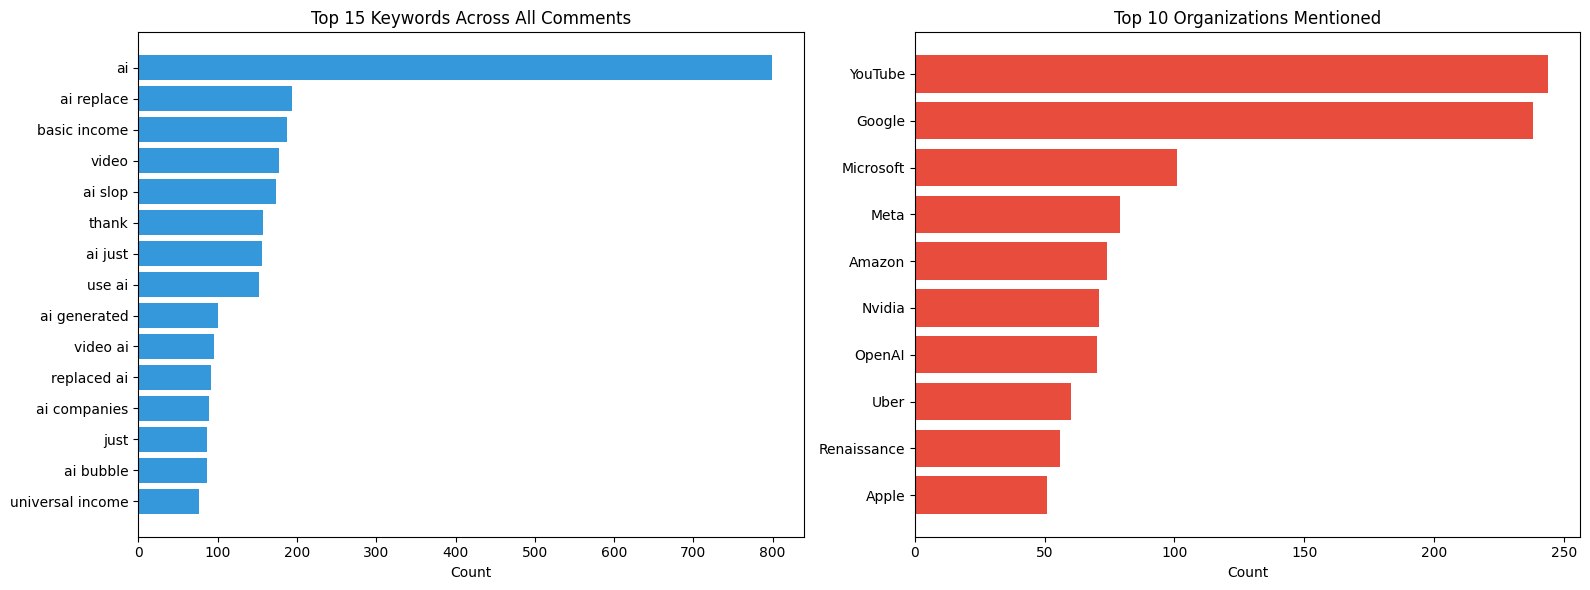

Chart saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top 15 keywords
top_kws = dict(keyword_counts.most_common(15))
axes[0].barh(list(top_kws.keys()), list(top_kws.values()), color="#3498db")
axes[0].set_title("Top 15 Keywords Across All Comments")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# top 10 organizations
top_orgs = dict(org_counter.most_common(10))
axes[1].barh(list(top_orgs.keys()), list(top_orgs.values()), color="#e74c3c")
axes[1].set_title("Top 10 Organizations Mentioned")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/ner_keywords_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [15]:
# convert entity lists to strings for CSV storage
# lists can't be saved directly to CSV - we store as string and parse back when needed
df["entities"] = df["entities"].apply(str)
df["keywords"] = df["keywords"].apply(str)

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/comments_enriched.csv", index=False, encoding="utf-8-sig")

print(f"Saved {len(df)} rows to comments_enriched.csv")
print("Columns:", df.columns.tolist())

Saved 27330 rows to comments_enriched.csv
Columns: ['video_id', 'video_name', 'comment_id', 'author', 'text', 'likes', 'published_at', 'reply_count', 'text_clean', 'text_lemma', 'text_for_model', 'sentiment', 'score_negative', 'score_neutral', 'score_positive', 'confidence', 'topic', 'topic_name', 'entities', 'keywords']
